### Visualización

---

#### Imports

In [4]:
from src.helpers.carga_datos import CargadorDatos
from src.eda.EDA import ProcesadorEDA

import matplotlib.pyplot as plt
import seaborn as sns

#### Cargar y Procesar Datos

In [5]:
cargador = CargadorDatos("../data/raw/tmdb_2020_to_2025.csv")
df = cargador.cargar()

eda = ProcesadorEDA(df)
df = eda.limpiar_datos()

df.head()

,adult,genre_ids,id,original_language,original_title,overview,popularity,release_date,title,video,vote_average,vote_count,year
1,False,"[10749, 18]",1231813,ko,자매의 스와핑,Sisters Ji-soo and Ji-yeong decided to sell th...,14.2714,2023-12-19,Sister Swapping,False,6.600,14,2023
86,False,"[10402, 35]",975225,en,Spinal Tap II: The End Continues,The now estranged bandmates of Spinal Tap are ...,26.3853,2025-09-12,Spinal Tap II: The End Continues,False,6.800,20,2025
93,False,[35],1358831,es,Voy a pasármelo mejor,Sin descripción,21.9851,2025-07-18,Voy a pasármelo mejor,False,7.929,7,2025
98,False,[18],1033148,en,Die My Love,"Grace, a writer and young mother, is slowly sl...",25.4301,2025-10-06,Die My Love,False,6.800,24,2025
99,False,"[18, 10749]",1549512,tl,Nympho,A woman seeking excitement meets a man who bri...,24.3173,2025-11-07,Nympho,False,8.000,17,2025


In [6]:
df_limpio = eda.limpiar_datos()

In [7]:
df_limpio.head()

,adult,genre_ids,id,original_language,original_title,overview,popularity,release_date,title,video,vote_average,vote_count,year
1,False,"[10749, 18]",1231813,ko,자매의 스와핑,Sisters Ji-soo and Ji-yeong decided to sell th...,14.2714,2023-12-19,Sister Swapping,False,6.600,14,2023
109,False,[],940675,ko,하숙집 : 그녀들의 신음소리 2,Smith's boarding house. Women feel the void in...,0.1929,2021-02-22,Boarding House: Their Moans 2,False,0.000,0,2021
157,False,[18],1304366,en,Average Joe,"After a troubled childhood, a former Marine be...",15.7226,2024-10-10,Average Joe,False,3.900,7,2024
173,False,"[27, 53, 18, 10770]",949855,en,Black Mold,Photographers Brooke Konrad and Tanner Behlman...,15.9634,2025-01-30,Black Mold,False,5.154,13,2025
176,False,"[35, 18, 10749]",1267905,en,The Roses,Life seems easy for picture-perfect couple Ivy...,16.1367,2025-08-27,The Roses,False,6.800,324,2025


### Histograma de popularidad

---

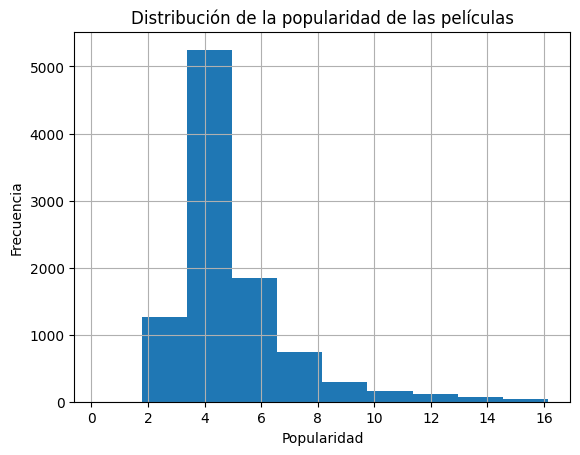

In [5]:
plt.figure()
df_limpio['popularity'].hist()
plt.title("Distribución de la popularidad de las películas")
plt.xlabel("Popularidad")
plt.ylabel("Frecuencia")
plt.show()

Se observa que la mayoría de las películas presentan niveles bajos de popularidad, con pocos valores extremos, lo que indica una distribución sesgada hacia valores bajos.

#### Relación votos vs popularidad

---

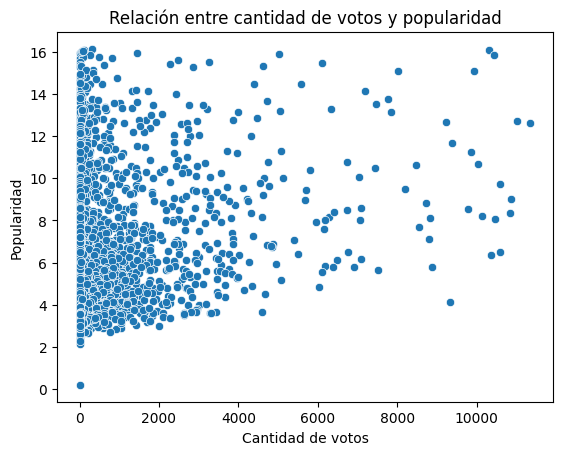

In [6]:
plt.figure()
sns.scatterplot(x='vote_count', y='popularity', data=df_limpio)
plt.title("Relación entre cantidad de votos y popularidad")
plt.xlabel("Cantidad de votos")
plt.ylabel("Popularidad")
plt.show()

Se evidencia una relación positiva entre la cantidad de votos y la popularidad, lo que sugiere que las películas con mayor interacción tienden a ser más reconocidas.

#### Matriz de correlación

---

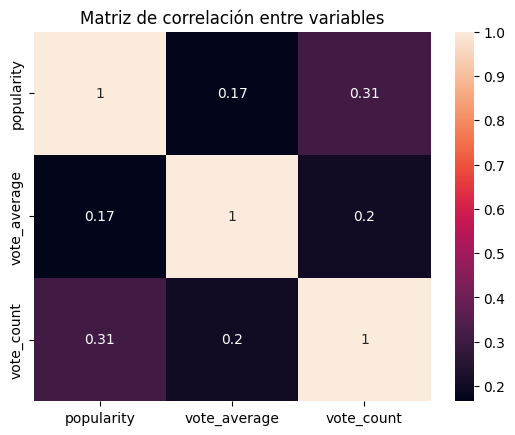

In [7]:
plt.figure()
corr = df_limpio[['popularity','vote_average','vote_count']].corr()
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación entre variables")
plt.show()

La matriz de correlación muestra que la variable "vote_count" tiene mayor relación con la popularidad en comparación con la calificación promedio, lo que indica que la cantidad de votos influye más en la visibilidad de una película.

#### Películas por año

---

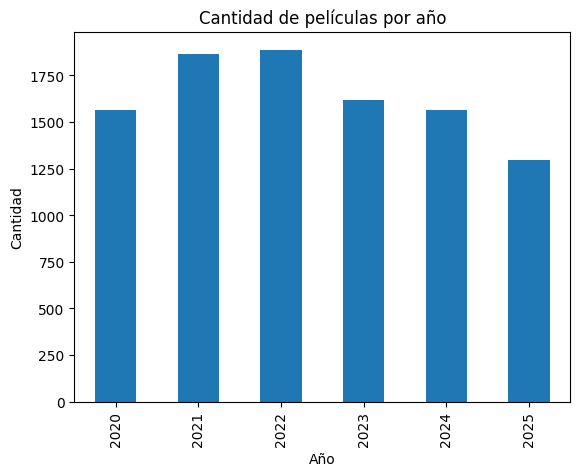

In [8]:
plt.figure()
df_limpio['year'].value_counts().sort_index().plot(kind='bar')
plt.title("Cantidad de películas por año")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.show()

Se observa una variación en la cantidad de películas lanzadas por año, lo que puede reflejar cambios en la producción cinematográfica o en la disponibilidad de datos.

In [9]:
print("Dimensiones del dataset limpio:", df_limpio.shape)

Dimensiones del dataset limpio: (9800, 13)
